# External Factors Integration for Traffic Demand

This notebook integrates **hourly external weather factors** from Meteostat into the capstone traffic dataset for Issue #10. The goal is to enrich the traffic records with weather and temporal context, evaluate how those factors relate to traffic demand, and export a reusable dataset for future forecasting experiments.


## 1. Title and Objective

This notebook extends the capstone workflow by integrating **hourly Toronto weather observations** into the project’s hourly traffic dataset. The objective is to enrich the traffic records with external context, evaluate how temporal and weather-related factors relate to traffic demand, and prepare a reusable dataset for future forecasting experiments.


## 2. Load Traffic Dataset

This section loads the canonical **hourly processed traffic dataset** already used elsewhere in the repository. Reporting its shape, columns, and preview at the outset keeps the workflow transparent and confirms that the analysis is grounded in the same hourly signal used in the broader capstone pipeline.


In [71]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start


PROJECT_ROOT = find_repo_root(Path.cwd())
TRAFFIC_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "traffic_signal_hourly_dataset_2015_2019.csv"

if not TRAFFIC_DATA_PATH.exists():
    raise FileNotFoundError(
        "Expected hourly processed traffic dataset was not found: "
        f"{TRAFFIC_DATA_PATH}"
    )

traffic_path = TRAFFIC_DATA_PATH
traffic_df = pd.read_csv(traffic_path)

display(Markdown(f"**Loaded dataset:** `{traffic_path}`"))
display(pd.DataFrame({"Rows": [traffic_df.shape[0]], "Columns": [traffic_df.shape[1]]}))
display(pd.DataFrame({"Column Name": traffic_df.columns}))
display(traffic_df.head())

**Loaded dataset:** `/Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/traffic_signal_hourly_dataset_2015_2019.csv`

,Rows,Columns
0,138672,21


,Column Name
0,location_id
1,hour
2,hourly_volume
3,location_name
4,centreline_id
5,direction
6,date
7,hour_of_day
8,year
9,month


,location_id,hour,hourly_volume,location_name,centreline_id,direction,date,hour_of_day,year,month,day_of_week,is_weekend,daily_total_volume,peak_hour_volume,peak_ratio,peak_hour_concentration,observed_hour_count,hourly_share_of_daily_volume,is_peak_hour,estimated_arrival_rate_vph,estimated_arrival_rate_vpm
0,10010625_WB,2015-05-14 00:00:00,286,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,0,2015,5,3,0,17031,1809,0.106,2.549,24,0.017,0,286,4.767
1,10010625_WB,2015-05-14 01:00:00,198,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,1,2015,5,3,0,17031,1809,0.106,2.549,24,0.012,0,198,3.300
2,10010625_WB,2015-05-14 02:00:00,134,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2,2015,5,3,0,17031,1809,0.106,2.549,24,0.008,0,134,2.233
3,10010625_WB,2015-05-14 03:00:00,118,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,3,2015,5,3,0,17031,1809,0.106,2.549,24,0.007,0,118,1.967
4,10010625_WB,2015-05-14 04:00:00,131,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,4,2015,5,3,0,17031,1809,0.106,2.549,24,0.008,0,131,2.183


## 3. Identify and Parse Timestamp

Traffic and weather data can only be merged reliably when they share a clean hourly timestamp. This section automatically detects the most likely datetime field, parses it, renames it to `timestamp`, identifies the main traffic-demand column, and standardizes the core analysis table.


In [72]:
timestamp_candidates = [
    "timestamp",
    "datetime",
    "hour",
    "analysis_timestamp",
    "forecast_timestamp",
    "ds",
    "count_date",
    "date",
]
traffic_candidates = [
    "traffic_demand",
    "hourly_volume",
    "traffic_volume",
    "volume",
    "total_volume",
    "daily_total_volume",
    "predicted_volume",
]


def detect_datetime_column(df: pd.DataFrame, candidates: list[str]) -> str:
    best_column = None
    best_score = None

    for priority, column in enumerate(candidates):
        if column not in df.columns:
            continue
        parsed = pd.to_datetime(df[column], errors="coerce")
        valid = parsed.dropna()
        if valid.empty:
            continue

        unique_timestamps = valid.nunique()
        unique_hours = valid.dt.hour.nunique()
        has_hourly_resolution = int(unique_hours > 1 or unique_timestamps > valid.dt.normalize().nunique())
        score = (has_hourly_resolution, unique_timestamps, -priority)

        if best_score is None or score > best_score:
            best_column = column
            best_score = score

    if best_column is not None:
        return best_column

    raise ValueError(
        "No usable timestamp column was found. Checked candidates: "
        + ", ".join(candidates)
    )



def detect_traffic_column(df: pd.DataFrame, candidates: list[str]) -> str:
    for column in candidates:
        if column in df.columns and pd.api.types.is_numeric_dtype(df[column]):
            return column

    raise ValueError(
        "No traffic demand column was found. Checked candidates: "
        + ", ".join(candidates)
    )


chosen_timestamp = detect_datetime_column(traffic_df, timestamp_candidates)
traffic_df[chosen_timestamp] = pd.to_datetime(traffic_df[chosen_timestamp], errors="coerce")
if traffic_df[chosen_timestamp].notna().sum() == 0:
    raise ValueError(f"Timestamp column '{chosen_timestamp}' could not be parsed into datetimes.")

chosen_traffic = detect_traffic_column(traffic_df, traffic_candidates)

traffic_df = traffic_df.rename(columns={chosen_timestamp: "timestamp", chosen_traffic: "traffic_demand"}).copy()
traffic_df = traffic_df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
traffic_df["timestamp"] = pd.to_datetime(traffic_df["timestamp"]).dt.floor("h")

selected_summary = pd.DataFrame(
    {
        "detected_timestamp_column": [chosen_timestamp],
        "detected_traffic_column": [chosen_traffic],
        "min_timestamp": [traffic_df["timestamp"].min()],
        "max_timestamp": [traffic_df["timestamp"].max()],
        "unique_hour_values_in_source": [traffic_df["timestamp"].dt.hour.nunique()],
    }
)

display(selected_summary)
display(Markdown(f"**Selected traffic target column:** `{chosen_traffic}`"))
display(traffic_df.head())


,detected_timestamp_column,detected_traffic_column,min_timestamp,max_timestamp,unique_hour_values_in_source
0,hour,hourly_volume,2015-03-31,2019-11-05 23:00:00,24


**Selected traffic target column:** `hourly_volume`

,location_id,timestamp,traffic_demand,location_name,centreline_id,direction,date,hour_of_day,year,month,day_of_week,is_weekend,daily_total_volume,peak_hour_volume,peak_ratio,peak_hour_concentration,observed_hour_count,hourly_share_of_daily_volume,is_peak_hour,estimated_arrival_rate_vph,estimated_arrival_rate_vpm
0,20146476_EB,2015-03-31,207,Progress Ave: Cosentino Dr - Schick Crt,20146476,EB,2015-03-31,0,2015,3,1,0,7820,816,0.104,2.504,24,0.026,0,207,3.450
1,7963316_SB,2015-03-31,98,Scarlett Rd: St Clair Ave W - Bernice Cres,7963316,SB,2015-03-31,0,2015,3,1,0,10766,884,0.082,1.971,24,0.009,0,98,1.633
2,107416_EB,2015-03-31,66,Progress Ave: Grangeway Ave - Bellamy Rd N,107416,EB,2015-03-31,0,2015,3,1,0,7561,890,0.118,2.825,24,0.009,0,66,1.100
3,9278721_WB,2015-03-31,27,Rathburn Rd: Remington Dr - Kipling Ave,9278721,WB,2015-03-31,0,2015,3,1,0,4617,422,0.091,2.194,24,0.006,0,27,0.450
4,9655658_EB,2015-03-31,173,Rexdale Blvd: Kipling Ave - Brydon Dr,9655658,EB,2015-03-31,0,2015,3,1,0,17653,1324,0.075,1.800,24,0.010,0,173,2.883


## 4. Retrieve Hourly Weather Data from Meteostat

Weather is retrieved using Meteostat's hourly point-data workflow for downtown Toronto (`43.6532`, `-79.3832`). Matching the traffic date range keeps the external data aligned with the capstone analysis window and avoids introducing unnecessary observations.


In [73]:
try:
    from meteostat.api.config import config
    from meteostat.api.hourly import hourly
    from meteostat.api.point import Point
    from meteostat.api.stations import Stations
except ImportError as exc:
    raise ImportError(
        "The 'meteostat' package is required for this notebook. Install it with `pip install meteostat`."
    ) from exc

config.block_large_requests = False

toronto_point = Point(43.6532, -79.3832)
start = traffic_df["timestamp"].min().to_pydatetime()
end = traffic_df["timestamp"].max().to_pydatetime()

def fetch_hourly_weather(query_target, start_dt, end_dt):
    weather_frames = []
    for year in range(start_dt.year, end_dt.year + 1):
        chunk_start = max(start_dt, pd.Timestamp(year=year, month=1, day=1).to_pydatetime())
        chunk_end = min(end_dt, pd.Timestamp(year=year, month=12, day=31, hour=23).to_pydatetime())
        weather_ts = hourly(query_target, chunk_start, chunk_end)
        weather_chunk = weather_ts.fetch() if weather_ts is not None else None
        if weather_chunk is None or weather_chunk.empty:
            warnings.warn(f"No Meteostat hourly weather data returned for {year}.")
            continue
        weather_frames.append(weather_chunk.reset_index())
    return weather_frames

weather_frames = fetch_hourly_weather(toronto_point, start, end)
weather_source_label = "Toronto point query"

if not weather_frames:
    nearby_stations = Stations().nearby(toronto_point, limit=1)
    if nearby_stations.empty:
        raise ValueError("Meteostat could not resolve a nearby Toronto weather station.")
    nearest_station_id = nearby_stations.index[0]
    weather_source_label = f"Nearest station fallback ({nearest_station_id})"
    weather_frames = fetch_hourly_weather(nearest_station_id, start, end)

if not weather_frames:
    raise ValueError(
        "Meteostat returned no hourly weather data for the traffic date range."
    )

weather_df = pd.concat(weather_frames, ignore_index=True)
time_column = "time" if "time" in weather_df.columns else weather_df.columns[0]
weather_df = weather_df.rename(columns={time_column: "timestamp"})

relevant_weather_columns = ["temp", "dwpt", "rhum", "prcp", "snow", "wspd", "pres", "tsun", "coco"]
available_weather_columns = [column for column in relevant_weather_columns if column in weather_df.columns]
weather_df = weather_df[["timestamp", *available_weather_columns]].copy()

display(Markdown(f"**Weather source used:** {weather_source_label}"))
display(pd.DataFrame({"rows": [weather_df.shape[0]], "columns": [weather_df.shape[1]]}))
display(weather_df.head())


/var/folders/l8/rx_wt20x4c966gjn1rlgl_f40000gn/T/ipykernel_34083/999799142.py:25: UserWarning: No Meteostat hourly weather data returned for 2015.
  warnings.warn(f"No Meteostat hourly weather data returned for {year}.")
/var/folders/l8/rx_wt20x4c966gjn1rlgl_f40000gn/T/ipykernel_34083/999799142.py:25: UserWarning: No Meteostat hourly weather data returned for 2016.
  warnings.warn(f"No Meteostat hourly weather data returned for {year}.")
/var/folders/l8/rx_wt20x4c966gjn1rlgl_f40000gn/T/ipykernel_34083/999799142.py:25: UserWarning: No Meteostat hourly weather data returned for 2017.
  warnings.warn(f"No Meteostat hourly weather data returned for {year}.")
/var/folders/l8/rx_wt20x4c966gjn1rlgl_f40000gn/T/ipykernel_34083/999799142.py:25: UserWarning: No Meteostat hourly weather data returned for 2018.
  warnings.warn(f"No Meteostat hourly weather data returned for {year}.")
/var/folders/l8/rx_wt20x4c966gjn1rlgl_f40000gn/T/ipykernel_34083/999799142.py:25: UserWarning: No Meteostat hourly w

**Weather source used:** Nearest station fallback (71508)

,rows,columns
0,40166,8


,timestamp,temp,rhum,prcp,wspd,pres,tsun,coco
0,2015-03-31 00:00:00,3.000,60,0.000,0.000,"1,011.000",<NA>,<NA>
1,2015-03-31 01:00:00,2.700,58,0.000,<NA>,"1,011.600",<NA>,<NA>
2,2015-03-31 02:00:00,2.200,61,0.000,<NA>,"1,012.200",<NA>,<NA>
3,2015-03-31 03:00:00,1.200,65,0.000,<NA>,"1,012.600",<NA>,<NA>
4,2015-03-31 04:00:00,1.100,68,0.000,<NA>,"1,012.900",<NA>,<NA>


## 5. Prepare and Merge Weather Data

Before merging, both datasets must use timezone-compatible hourly timestamps. This section removes timezone information where needed, aligns each table to the hour, performs a left join from traffic to weather, and reports how complete the weather enrichment was.


In [74]:
def make_timezone_naive(series: pd.Series) -> pd.Series:
    dt_series = pd.to_datetime(series, errors="coerce")
    tz = getattr(dt_series.dt, "tz", None)
    if tz is not None:
        return dt_series.dt.tz_localize(None)
    return dt_series


traffic_df["timestamp"] = make_timezone_naive(traffic_df["timestamp"]).dt.floor("h")
weather_df["timestamp"] = make_timezone_naive(weather_df["timestamp"]).dt.floor("h")

weather_df = weather_df.sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last")
merged_df = traffic_df.merge(weather_df, on="timestamp", how="left", validate="m:1")

missing_weather_counts = merged_df[available_weather_columns].isna().sum().rename("missing_values") if available_weather_columns else pd.Series(dtype="int64")
merge_success_rate = (
    merged_df[available_weather_columns].notna().any(axis=1).mean() * 100
    if available_weather_columns
    else 0.0
)

display(Markdown(f"**Merge success rate:** {merge_success_rate:.2f}% of traffic rows matched at least one weather field."))
if available_weather_columns:
    display(missing_weather_counts.to_frame())
else:
    warnings.warn("No requested weather columns were returned by Meteostat for the selected range.")

display(merged_df.head())


**Merge success rate:** 99.65% of traffic rows matched at least one weather field.

,missing_values
temp,484
rhum,484
prcp,5895
wspd,102643
pres,1786
tsun,138672
coco,138672


,location_id,timestamp,traffic_demand,location_name,centreline_id,direction,date,hour_of_day,year,month,day_of_week,is_weekend,daily_total_volume,peak_hour_volume,peak_ratio,peak_hour_concentration,observed_hour_count,hourly_share_of_daily_volume,is_peak_hour,estimated_arrival_rate_vph,estimated_arrival_rate_vpm,temp,rhum,prcp,wspd,pres,tsun,coco
0,20146476_EB,2015-03-31,207,Progress Ave: Cosentino Dr - Schick Crt,20146476,EB,2015-03-31,0,2015,3,1,0,7820,816,0.104,2.504,24,0.026,0,207,3.450,3.000,60,0.000,0.000,"1,011.000",<NA>,<NA>
1,7963316_SB,2015-03-31,98,Scarlett Rd: St Clair Ave W - Bernice Cres,7963316,SB,2015-03-31,0,2015,3,1,0,10766,884,0.082,1.971,24,0.009,0,98,1.633,3.000,60,0.000,0.000,"1,011.000",<NA>,<NA>
2,107416_EB,2015-03-31,66,Progress Ave: Grangeway Ave - Bellamy Rd N,107416,EB,2015-03-31,0,2015,3,1,0,7561,890,0.118,2.825,24,0.009,0,66,1.100,3.000,60,0.000,0.000,"1,011.000",<NA>,<NA>
3,9278721_WB,2015-03-31,27,Rathburn Rd: Remington Dr - Kipling Ave,9278721,WB,2015-03-31,0,2015,3,1,0,4617,422,0.091,2.194,24,0.006,0,27,0.450,3.000,60,0.000,0.000,"1,011.000",<NA>,<NA>
4,9655658_EB,2015-03-31,173,Rexdale Blvd: Kipling Ave - Brydon Dr,9655658,EB,2015-03-31,0,2015,3,1,0,17653,1324,0.075,1.800,24,0.010,0,173,2.883,3.000,60,0.000,0.000,"1,011.000",<NA>,<NA>


## 6. External Feature Engineering

External-factor engineering converts timestamps and weather conditions into analysis-ready indicators. These features provide direct candidates for future forecasting models and make it easier to compare demand across peak periods, weekends, rain events, snow events, and cold-weather conditions.


In [75]:
merged_df["hour_of_day"] = merged_df["timestamp"].dt.hour
merged_df["day_of_week"] = merged_df["timestamp"].dt.dayofweek
merged_df["is_weekend"] = (merged_df["day_of_week"] >= 5).astype(int)
merged_df["is_peak_hour"] = merged_df["hour_of_day"].isin([7, 8, 9, 16, 17, 18]).astype(int)

if "prcp" in merged_df.columns:
    merged_df["is_rain"] = (merged_df["prcp"].fillna(0) > 0).astype(int)
else:
    warnings.warn("Weather column 'prcp' is unavailable, so 'is_rain' was skipped.")

if "snow" in merged_df.columns:
    merged_df["is_snow"] = (merged_df["snow"].fillna(0) > 0).astype(int)
elif "snwd" in merged_df.columns:
    merged_df["is_snow"] = (merged_df["snwd"].fillna(0) > 0).astype(int)
else:
    warnings.warn("Weather columns 'snow'/'snwd' are unavailable, so 'is_snow' was skipped.")

if "temp" in merged_df.columns:
    merged_df["cold_weather"] = (merged_df["temp"] < 0).fillna(False).astype(int)
else:
    warnings.warn("Weather column 'temp' is unavailable, so 'cold_weather' was skipped.")

print("Min timestamp:", merged_df["timestamp"].min())
print("Max timestamp:", merged_df["timestamp"].max())
print("Number of unique dates:", merged_df["timestamp"].dt.date.nunique())
print("Unique hour values:", sorted(merged_df["timestamp"].dt.hour.dropna().unique().tolist()))
print("Number of unique hour values present:", merged_df["timestamp"].dt.hour.nunique())

hour_counts = merged_df["hour_of_day"].value_counts().sort_index().rename("count")
peak_counts = merged_df["is_peak_hour"].value_counts().sort_index().rename("count")

display(hour_counts.to_frame())
display(peak_counts.to_frame())

validation_messages = []
if merged_df["hour_of_day"].nunique() <= 1:
    validation_messages.append("Hourly validation warning: only one hour-of-day value is present after feature engineering.")
if merged_df["is_peak_hour"].nunique() <= 1:
    validation_messages.append("Peak-hour validation warning: only one peak/non-peak category is present after feature engineering.")

if validation_messages:
    display(Markdown("\n".join(f"**Warning:** {message}" for message in validation_messages)))
else:
    display(Markdown("**Hourly validation check:** hourly timestamps span multiple hours and both peak/non-peak categories are present."))

feature_preview_columns = [
    column for column in [
        "timestamp",
        "traffic_demand",
        "temp",
        "prcp",
        "snow",
        "snwd",
        "hour_of_day",
        "day_of_week",
        "is_weekend",
        "is_peak_hour",
        "is_rain",
        "is_snow",
        "cold_weather",
    ] if column in merged_df.columns
]

display(merged_df[feature_preview_columns].head())


Min timestamp: 2015-03-31 00:00:00
Max timestamp: 2019-11-05 23:00:00
Number of unique dates: 273
Unique hour values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Number of unique hour values present: 24


/var/folders/l8/rx_wt20x4c966gjn1rlgl_f40000gn/T/ipykernel_34083/194251586.py:16: UserWarning: Weather columns 'snow'/'snwd' are unavailable, so 'is_snow' was skipped.
  warnings.warn("Weather columns 'snow'/'snwd' are unavailable, so 'is_snow' was skipped.")


,count
hour_of_day,
0,5778
1,5778
2,5778
3,5778
4,5778
5,5778
6,5778
7,5778
8,5778


,count
is_peak_hour,
0,104004
1,34668


**Hourly validation check:** hourly timestamps span multiple hours and both peak/non-peak categories are present.

,timestamp,traffic_demand,temp,prcp,hour_of_day,day_of_week,is_weekend,is_peak_hour,is_rain,cold_weather
0,2015-03-31,207,3.000,0.000,0,1,0,0,0,0
1,2015-03-31,98,3.000,0.000,0,1,0,0,0,0
2,2015-03-31,66,3.000,0.000,0,1,0,0,0,0
3,2015-03-31,27,3.000,0.000,0,1,0,0,0,0
4,2015-03-31,173,3.000,0.000,0,1,0,0,0,0


## 7. Exploratory Analysis of External Factors

The exploratory analysis focuses on interpretable comparisons that are useful for presentation and later modeling decisions. The visuals below compare traffic demand across peak and non-peak periods, wet and dry conditions, temperature ranges, hourly demand cycles, and weekly calendar patterns while keeping the interpretation descriptive rather than causal.


/var/folders/l8/rx_wt20x4c966gjn1rlgl_f40000gn/T/ipykernel_34083/2111469026.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=peak_profile, x="label", y="traffic_demand", palette=["#9ecae1", "#3182bd"], ax=axes[0])
/var/folders/l8/rx_wt20x4c966gjn1rlgl_f40000gn/T/ipykernel_34083/2111469026.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rain_profile, x="label", y="traffic_demand", palette=["#b8e186", "#4d9221"], ax=axes[1])
/var/folders/l8/rx_wt20x4c966gjn1rlgl_f40000gn/T/ipykernel_34083/2111469026.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the 

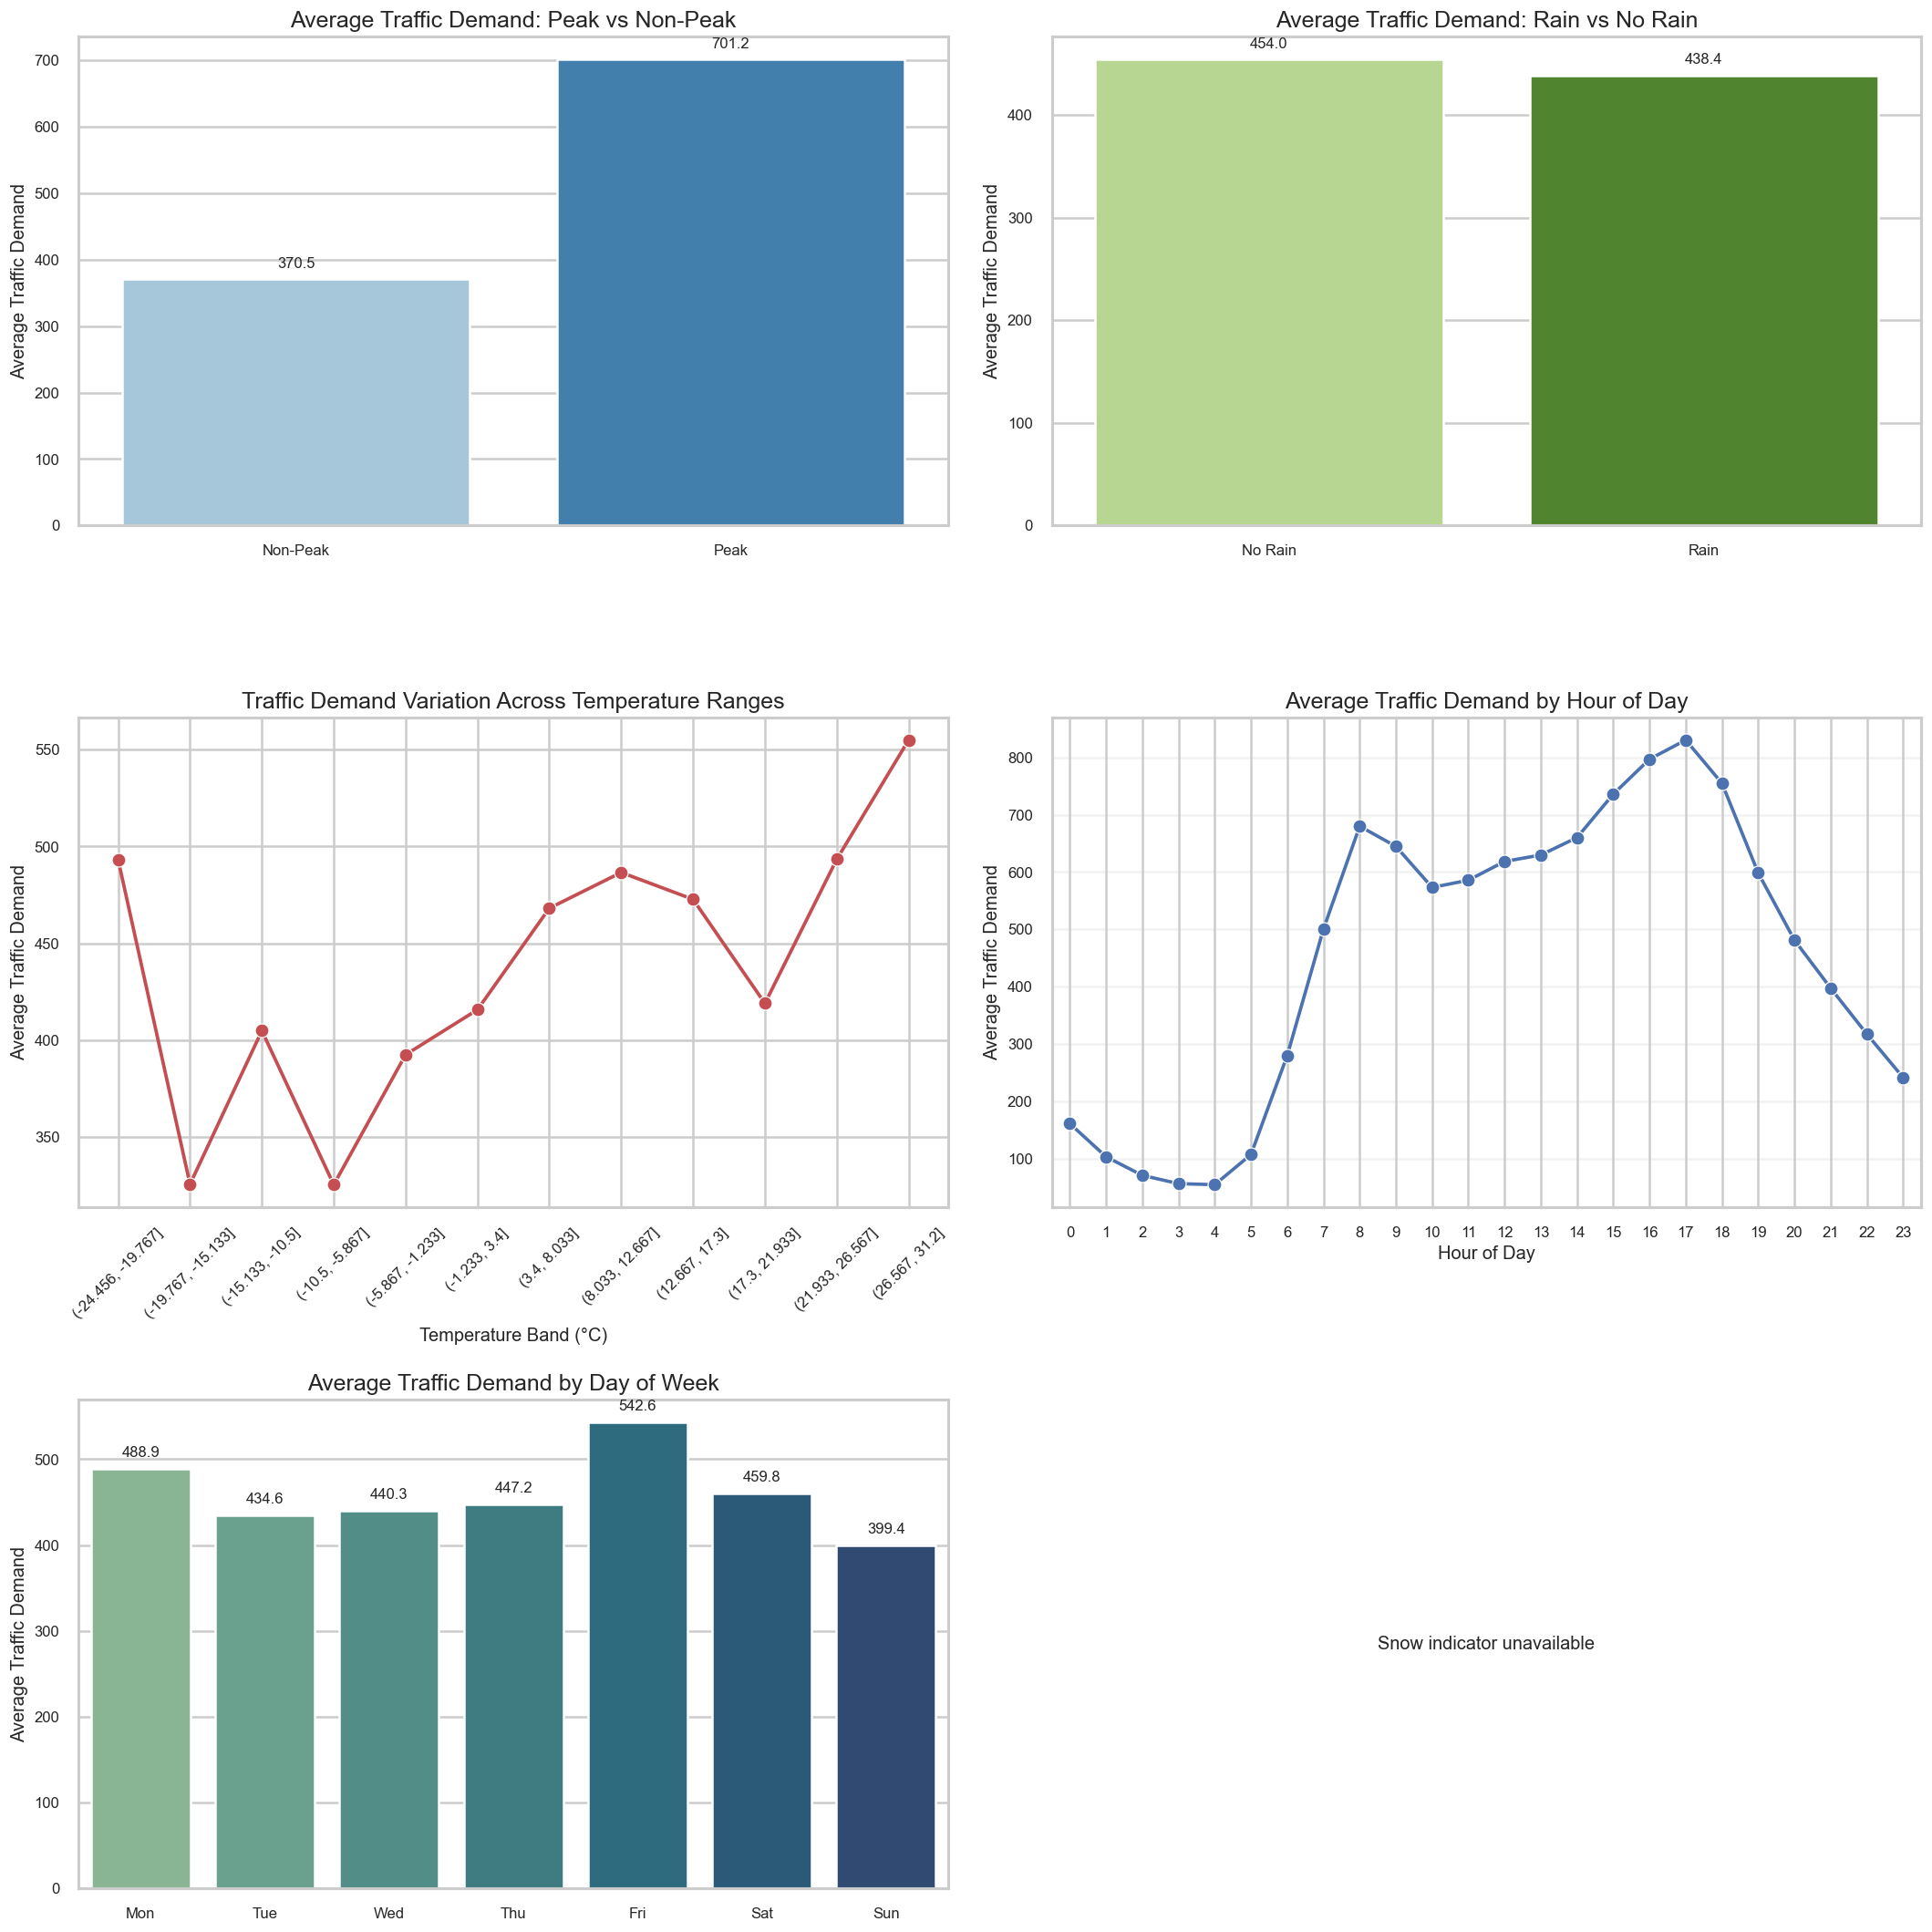

Temperature-band differences in the plot above are descriptive rather than causal. Traffic demand varies across temperature ranges, but the overall linear relationship remains weak, so temperature should be interpreted as contextual signal rather than a dominant predictor.

In [76]:
def annotate_bars(ax, decimals: int = 0) -> None:
    for patch in ax.patches:
        height = patch.get_height()
        if pd.notna(height):
            ax.annotate(
                f"{height:,.{decimals}f}",
                (patch.get_x() + patch.get_width() / 2, height),
                ha="center",
                va="bottom",
                xytext=(0, 6),
                textcoords="offset points",
                fontsize=10,
            )


fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

peak_profile = merged_df.groupby("is_peak_hour", as_index=False)["traffic_demand"].mean()
peak_profile = peak_profile.set_index("is_peak_hour").reindex([0, 1]).reset_index()
peak_profile["label"] = ["Non-Peak", "Peak"]
sns.barplot(data=peak_profile, x="label", y="traffic_demand", palette=["#9ecae1", "#3182bd"], ax=axes[0])
axes[0].set_title("Average Traffic Demand: Peak vs Non-Peak")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average Traffic Demand")
annotate_bars(axes[0], decimals=1)

if "is_rain" in merged_df.columns:
    rain_profile = merged_df.groupby("is_rain", as_index=False)["traffic_demand"].mean()
    rain_profile = rain_profile.set_index("is_rain").reindex([0, 1]).reset_index()
    rain_profile["label"] = ["No Rain", "Rain"]
    sns.barplot(data=rain_profile, x="label", y="traffic_demand", palette=["#b8e186", "#4d9221"], ax=axes[1])
    axes[1].set_title("Average Traffic Demand: Rain vs No Rain")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Average Traffic Demand")
    annotate_bars(axes[1], decimals=1)
else:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, "Rain indicator unavailable", ha="center", va="center", fontsize=12)

if "temp" in merged_df.columns and merged_df["temp"].notna().sum() > 1:
    temp_plot_df = merged_df[["temp", "traffic_demand"]].dropna().copy()
    temp_plot_df["temp_band"] = pd.cut(temp_plot_df["temp"], bins=12)
    temp_profile = temp_plot_df.groupby("temp_band", observed=False)["traffic_demand"].mean().reset_index()
    temp_profile = temp_profile.dropna(subset=["traffic_demand"])
    temp_profile["temp_label"] = temp_profile["temp_band"].astype(str)
    sns.lineplot(data=temp_profile, x="temp_label", y="traffic_demand", marker="o", color="#c44e52", ax=axes[2])
    axes[2].set_title("Traffic Demand Variation Across Temperature Ranges")
    axes[2].set_xlabel("Temperature Band (°C)")
    axes[2].set_ylabel("Average Traffic Demand")
    axes[2].tick_params(axis="x", rotation=45)
else:
    axes[2].axis("off")
    axes[2].text(0.5, 0.5, "Temperature data unavailable", ha="center", va="center", fontsize=12)

hourly_profile = merged_df.groupby("hour_of_day", as_index=False)["traffic_demand"].mean()
hourly_profile = hourly_profile.set_index("hour_of_day").reindex(range(24)).reset_index()
sns.lineplot(data=hourly_profile, x="hour_of_day", y="traffic_demand", marker="o", color="#4c72b0", linewidth=2.2, ax=axes[3])
axes[3].set_title("Average Traffic Demand by Hour of Day")
axes[3].set_xlabel("Hour of Day")
axes[3].set_ylabel("Average Traffic Demand")
axes[3].set_xticks(range(24))
axes[3].set_xlim(-0.5, 23.5)
axes[3].grid(axis="y", alpha=0.25)

weekday_profile = merged_df.groupby("day_of_week", as_index=False)["traffic_demand"].mean()
weekday_profile = weekday_profile.set_index("day_of_week").reindex(range(7)).reset_index()
weekday_profile["weekday_label"] = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.barplot(data=weekday_profile, x="weekday_label", y="traffic_demand", palette="crest", ax=axes[4])
axes[4].set_title("Average Traffic Demand by Day of Week")
axes[4].set_xlabel("")
axes[4].set_ylabel("Average Traffic Demand")
annotate_bars(axes[4], decimals=1)

if "is_snow" in merged_df.columns:
    snow_profile = merged_df.groupby("is_snow", as_index=False)["traffic_demand"].mean()
    snow_profile = snow_profile.set_index("is_snow").reindex([0, 1]).reset_index()
    snow_profile["label"] = ["No Snow", "Snow"]
    sns.barplot(data=snow_profile, x="label", y="traffic_demand", palette=["#dadaeb", "#756bb1"], ax=axes[5])
    axes[5].set_title("Average Traffic Demand: Snow vs No Snow")
    axes[5].set_xlabel("")
    axes[5].set_ylabel("Average Traffic Demand")
    annotate_bars(axes[5], decimals=1)
else:
    axes[5].axis("off")
    axes[5].text(0.5, 0.5, "Snow indicator unavailable", ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.show()

display(Markdown(
    "Temperature-band differences in the plot above are descriptive rather than causal. Traffic demand varies across temperature ranges, but the overall linear relationship remains weak, so temperature should be interpreted as contextual signal rather than a dominant predictor."
))


## 8. Correlation Analysis

Correlation does not establish causation, but it offers a compact view of which available external factors move most closely with traffic demand. The matrix below focuses on the main numeric weather and temporal indicators that are most relevant for short-term forecasting feature selection.


,traffic_demand,temp,prcp,pres,rhum,hour_of_day,is_peak_hour,is_weekend
traffic_demand,1.000,0.057,-0.010,0.047,0.001,0.346,0.359,-0.029
temp,0.057,1.000,-0.027,-0.332,-0.259,0.127,-0.012,-0.095
prcp,-0.010,-0.027,1.000,-0.068,0.113,-0.003,0.003,0.003
pres,0.047,-0.332,-0.068,1.000,-0.195,-0.019,0.007,0.141
rhum,0.001,-0.259,0.113,-0.195,1.000,-0.216,0.045,0.039
hour_of_day,0.346,0.127,-0.003,-0.019,-0.216,1.000,0.083,-0.000
is_peak_hour,0.359,-0.012,0.003,0.007,0.045,0.083,1.000,-0.000
is_weekend,-0.029,-0.095,0.003,0.141,0.039,-0.000,-0.000,1.000


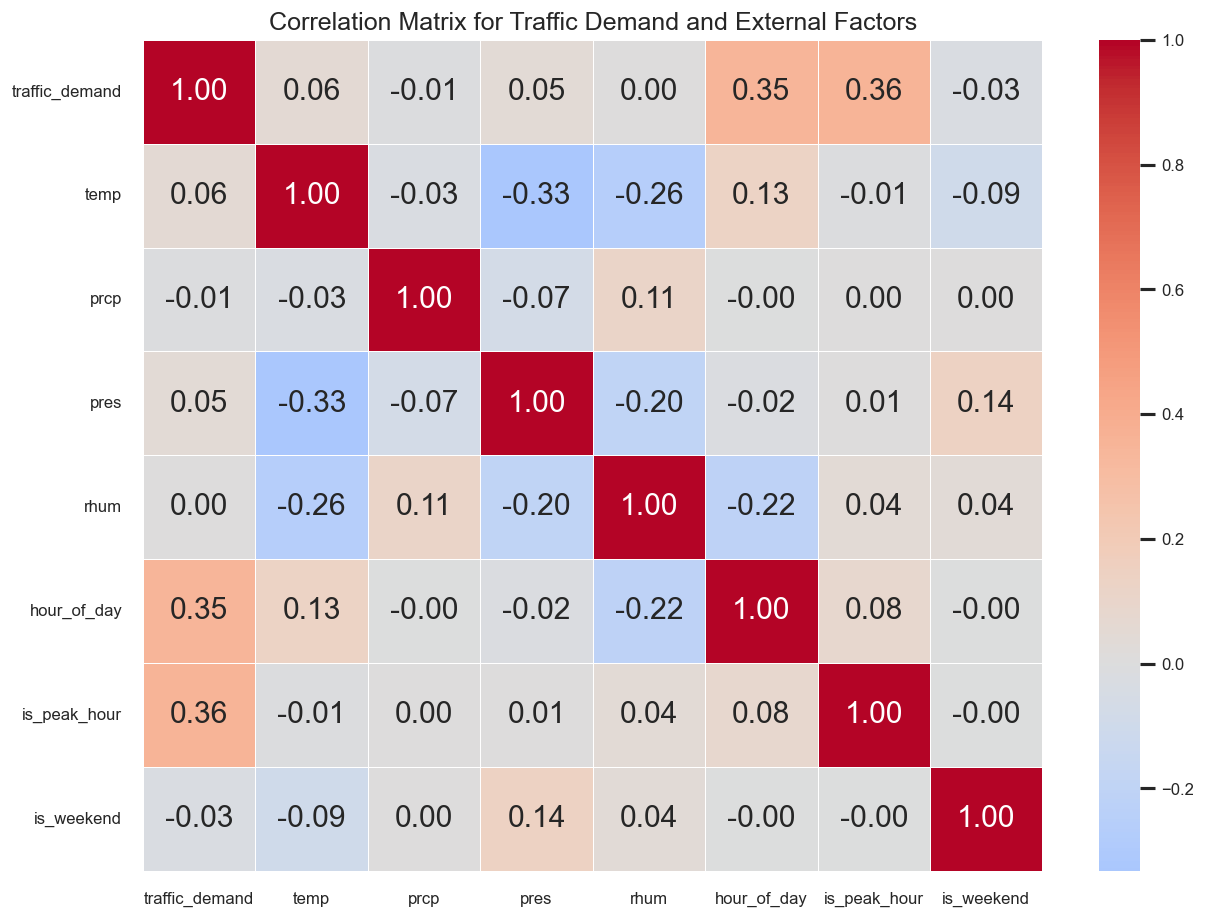

In [77]:
correlation_candidates = [
    "traffic_demand",
    "temp",
    "prcp",
    "pres",
    "rhum",
    "hour_of_day",
    "is_peak_hour",
    "is_weekend",
]

correlation_notes = []
filtered_corr_columns = []

for column in correlation_candidates:
    if column not in merged_df.columns:
        continue
    series = pd.to_numeric(merged_df[column], errors="coerce")
    missing_fraction = series.isna().mean()
    non_null = series.dropna()

    if non_null.empty:
        correlation_notes.append(f"Excluded `{column}` because it is entirely missing.")
        continue
    if missing_fraction > 0.7:
        correlation_notes.append(f"Excluded `{column}` because more than 70% of its values are missing.")
        continue
    if non_null.nunique() <= 1 or np.isclose(non_null.std(ddof=0), 0.0):
        correlation_notes.append(f"Excluded `{column}` because it has near-zero variance.")
        continue

    filtered_corr_columns.append(column)

if correlation_notes:
    display(Markdown("\n".join(f"- {note}" for note in correlation_notes)))

if len(filtered_corr_columns) < 2:
    warnings.warn("Not enough usable numeric columns are available to compute the corrected correlation matrix.")
    correlation_matrix = pd.DataFrame()
else:
    correlation_df = merged_df[filtered_corr_columns].apply(pd.to_numeric, errors="coerce")
    correlation_matrix = correlation_df.corr()
    display(correlation_matrix)
    plt.figure(figsize=(11, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
    plt.title("Correlation Matrix for Traffic Demand and External Factors")
    plt.tight_layout()
    plt.show()


## 9. Save Enriched Dataset

The enriched dataset is exported so later modeling notebooks can incorporate external factors without repeating the integration workflow. A compact interpreted summary table is also saved to make the key external-factor signals easy to reference in presentations, model documentation, and future experiments.


In [78]:
output_path = PROJECT_ROOT / "data" / "processed" / "traffic_with_external_factors.csv"
summary_path = PROJECT_ROOT / "data" / "processed" / "external_factors_summary.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

raw_metrics = {
    "mean_hourly_traffic_demand": float(merged_df["traffic_demand"].mean()),
    "median_hourly_traffic_demand": float(merged_df["traffic_demand"].median()),
    "merge_success_rate_pct": float(merge_success_rate),
}

if {0, 1}.issubset(set(merged_df["is_peak_hour"].dropna().unique())):
    peak_means = merged_df.groupby("is_peak_hour")["traffic_demand"].mean()
    raw_metrics["peak_minus_non_peak"] = float(peak_means.loc[1] - peak_means.loc[0])
    raw_metrics["mean_demand_non_peak"] = float(peak_means.loc[0])
    raw_metrics["mean_demand_peak"] = float(peak_means.loc[1])

if "is_rain" in merged_df.columns and {0, 1}.issubset(set(merged_df["is_rain"].dropna().unique())):
    rain_means = merged_df.groupby("is_rain")["traffic_demand"].mean()
    raw_metrics["rain_minus_no_rain"] = float(rain_means.loc[1] - rain_means.loc[0])
    raw_metrics["mean_demand_no_rain"] = float(rain_means.loc[0])
    raw_metrics["mean_demand_rain"] = float(rain_means.loc[1])

if {0, 1}.issubset(set(merged_df["is_weekend"].dropna().unique())):
    weekend_means = merged_df.groupby("is_weekend")["traffic_demand"].mean()
    raw_metrics["weekend_minus_weekday"] = float(weekend_means.loc[1] - weekend_means.loc[0])
    raw_metrics["mean_demand_weekday"] = float(weekend_means.loc[0])
    raw_metrics["mean_demand_weekend"] = float(weekend_means.loc[1])

if not correlation_matrix.empty and "traffic_demand" in correlation_matrix.columns:
    for column in ["temp", "prcp", "pres", "rhum", "hour_of_day", "is_peak_hour", "is_weekend"]:
        if column in correlation_matrix.index:
            raw_metrics[f"corr_traffic_demand_{column}"] = float(correlation_matrix.loc[column, "traffic_demand"])

summary_rows = []
if "peak_minus_non_peak" in raw_metrics:
    summary_rows.append({
        "Metric": "Peak vs Non-Peak difference",
        "Value": raw_metrics["peak_minus_non_peak"],
        "Interpretation": "Peak-hour demand is substantially higher, confirming that hourly temporal structure remains dominant.",
    })
if "rain_minus_no_rain" in raw_metrics:
    summary_rows.append({
        "Metric": "Rain vs No-Rain difference",
        "Value": raw_metrics["rain_minus_no_rain"],
        "Interpretation": "Rain is associated with only a small demand difference relative to average hourly demand, so the effect appears modest.",
    })
if "weekend_minus_weekday" in raw_metrics:
    summary_rows.append({
        "Metric": "Weekend vs Weekday difference",
        "Value": raw_metrics["weekend_minus_weekday"],
        "Interpretation": "Weekend demand is lower, indicating that calendar structure remains important alongside weather context.",
    })
if "corr_traffic_demand_temp" in raw_metrics:
    summary_rows.append({
        "Metric": "Temp correlation with traffic_demand",
        "Value": raw_metrics["corr_traffic_demand_temp"],
        "Interpretation": "The linear relationship is weak, so temperature is best treated as contextual signal rather than a dominant predictor.",
    })
if "corr_traffic_demand_prcp" in raw_metrics:
    summary_rows.append({
        "Metric": "Prcp correlation with traffic_demand",
        "Value": raw_metrics["corr_traffic_demand_prcp"],
        "Interpretation": "The linear association is weak and consistent with precipitation adding only modest explanatory value.",
    })
summary_rows.append({
    "Metric": "Weather merge success rate (%)",
    "Value": raw_metrics["merge_success_rate_pct"],
    "Interpretation": "Hourly weather coverage is high enough for downstream feature-based modeling experiments.",
})

summary_df = pd.DataFrame(summary_rows)
merged_df.to_csv(output_path, index=False)
summary_df.to_csv(summary_path, index=False)

summary_display_df = summary_df.copy()
summary_display_df["Value"] = summary_display_df["Value"].round(3)

styled_summary = (
    summary_display_df.style
    .hide(axis="index")
    .format({"Value": "{:,.3f}"})
    .set_properties(
        subset=["Metric"],
        **{
            "text-align": "left",
            "white-space": "normal",
            "min-width": "260px",
        },
    )
    .set_properties(
        subset=["Value"],
        **{
            "text-align": "left",
            "min-width": "110px",
        },
    )
    .set_properties(
        subset=["Interpretation"],
        **{
            "text-align": "left",
            "white-space": "normal",
            "word-wrap": "break-word",
            "min-width": "520px",
            "max-width": "700px",
        },
    )
    .set_table_styles(
        [
            {"selector": "th", "props": [("text-align", "left"), ("font-weight", "bold")]},
            {"selector": "td", "props": [("vertical-align", "top"), ("padding", "8px 10px")]},
            {"selector": "table", "props": [("width", "100%"), ("table-layout", "fixed")]},
        ]
    )
)

display(styled_summary)
display(Markdown(f"**Saved enriched dataset:** `{output_path}`  \n**Saved summary table:** `{summary_path}`"))


Metric,Value,Interpretation
Peak vs Non-Peak difference,330.703,"Peak-hour demand is substantially higher, confirming that hourly temporal structure remains dominant."
Rain vs No-Rain difference,-15.654,"Rain is associated with only a small demand difference relative to average hourly demand, so the effect appears modest."
Weekend vs Weekday difference,-28.828,"Weekend demand is lower, indicating that calendar structure remains important alongside weather context."
Temp correlation with traffic_demand,0.057,"The linear relationship is weak, so temperature is best treated as contextual signal rather than a dominant predictor."
Prcp correlation with traffic_demand,-0.010,The linear association is weak and consistent with precipitation adding only modest explanatory value.
Weather merge success rate (%),99.651,Hourly weather coverage is high enough for downstream feature-based modeling experiments.


**Saved enriched dataset:** `/Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/traffic_with_external_factors.csv`  
**Saved summary table:** `/Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/external_factors_summary.csv`

## 10. Findings and Discussion

This section translates the descriptive plots and summary metrics into concise analytical observations. The wording is intentionally cautious so that the discussion stays aligned with the evidence in the notebook and does not overstate the role of weather effects.


In [79]:
def qualitative_strength(value: float) -> str:
    absolute_value = abs(value)
    if np.isnan(absolute_value):
        return "not available"
    if absolute_value < 0.10:
        return "weak"
    if absolute_value < 0.30:
        return "moderate"
    return "strong"


peak_diff = raw_metrics.get("peak_minus_non_peak", np.nan)
rain_diff = raw_metrics.get("rain_minus_no_rain", np.nan)
weekend_diff = raw_metrics.get("weekend_minus_weekday", np.nan)
temp_corr = raw_metrics.get("corr_traffic_demand_temp", np.nan)
prcp_corr = raw_metrics.get("corr_traffic_demand_prcp", np.nan)
mean_hourly_demand = raw_metrics.get("mean_hourly_traffic_demand", np.nan)

findings_paragraphs = []

if not np.isnan(peak_diff):
    findings_paragraphs.append(
        f"Peak-hour demand is higher than non-peak demand by approximately {abs(peak_diff):,.2f} units on average, confirming that hourly temporal structure remains a dominant component of the traffic demand signal."
    )

if not np.isnan(rain_diff):
    rain_scale_note = ""
    if not np.isnan(mean_hourly_demand) and abs(rain_diff) < 0.05 * mean_hourly_demand:
        rain_scale_note = f" On an average hourly demand scale of about {mean_hourly_demand:,.0f} vehicles, this is a small difference."
    findings_paragraphs.append(
        f"Rain-associated demand is slightly lower than demand during dry periods by approximately {abs(rain_diff):,.2f} units on average. However, this difference is small and may reflect temporal overlap with commuting patterns rather than a direct causal weather effect.{rain_scale_note}"
    )

if not np.isnan(temp_corr):
    findings_paragraphs.append(
        f"Temperature shows a {qualitative_strength(temp_corr)} linear relationship with traffic demand (correlation {temp_corr:.2f}), suggesting that weather contributes contextual information but does not dominate the demand pattern. The temperature-band plot is therefore best read as descriptive variation across ranges rather than strong evidence of a dominant predictive effect."
    )

if not np.isnan(prcp_corr):
    findings_paragraphs.append(
        f"Precipitation has a {qualitative_strength(prcp_corr)} linear association with traffic demand (correlation {prcp_corr:.2f}), which is consistent with weather variables adding modest explanatory value rather than replacing core temporal predictors."
    )

if not np.isnan(weekend_diff):
    findings_paragraphs.append(
        f"Weekend demand is lower than weekday demand by approximately {abs(weekend_diff):,.2f} units on average, reinforcing that calendar structure remains important alongside weather context."
    )

findings_paragraphs.append(
    "Overall, the corrected hourly analysis suggests that external factors provide useful contextual information, while peak-period and broader temporal structure remain the primary drivers of variation in traffic demand."
)

findings_html = "".join(
    f'<p style="margin: 0 0 14px 0; line-height: 1.55;">{paragraph}</p>'
    for paragraph in findings_paragraphs
)
display(HTML(f'<div style="margin-top: 4px;">{findings_html}</div>'))


## 11. Conclusion and Next Steps

The traffic dataset has now been enriched with **hourly weather features from Meteostat** and aligned with the hourly traffic signal used elsewhere in the capstone workflow. The corrected analysis indicates that temporal features such as `hour_of_day` and `is_peak_hour` remain structurally important, while weather variables add modest explanatory value.

The next logical step is to compare forecasting models trained with and without these external-factor features so the project can quantify whether hourly weather context improves predictive performance beyond the baseline temporal demand structure.
